In [1]:
# imports
import pandas as pd
import os, joblib, math, time, random
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# reproduciblity
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# load the dataset
df = pd.read_csv("../data/heart_uci.csv")
# df.shape, df.columns.tolist()

# drop unnecessary features
df.drop(['id', 'dataset'], axis=1, inplace=True)

# Converts num to binary 0,1
df['num'] = (df['num'] > 0).astype(int)
# df['num'].value_counts()

df.dtypes
df.shape

(920, 14)

In [4]:
# 7 categorical and 6 numeric features found
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
target = 'num'

numeric_features, categorical_features

(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'],
 ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'])

In [4]:
# Numeric pipeline:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fill missing numeric values with median (robust)
    ("scaler", StandardScaler())                     # standardize for MLP and for stable SHAP input scaling
])

# Categorical pipeline:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill missing categories with the most frequent
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))  # one-hot encode; ignore unseen categories
])

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",    # drop any other columns (like id/dataset if present)
    sparse_threshold=0   # force dense output to make later code simpler
)

In [93]:
# Fit_transform on the whole data only as a quick sanity check (for debugging only).
# For proper modeling, you will fit the preprocessor inside a CV pipeline instead.
X = df.drop(columns=[target])
y = df[target]

# Quick sanity run (this fits the preprocess on the whole dataset — ok only for testing)
X_prepped = preprocessor.fit_transform(X)
print("Transformed shape:", X_prepped.shape)

Transformed shape: (920, 25)


In [100]:
# demo preprocessor on full data
joblib.dump(preprocessor, "../artifacts/preprocessor_initial.joblib")

['../artifacts/preprocessor_initial.joblib']

In [6]:
# Check sample transformed rows
X_sample = X_prepped[:5]
print("Sample row shape:", X_sample.shape)

# Check for NaNs after preprocessing
print("NaNs present after transform?:", np.isnan(X_prepped).any())

# Helper function: extract feature names from ColumnTransformer
def get_feature_names(column_transformer):
    names = []
    for name, transformer, cols in column_transformer.transformers_:
        if name == "remainder":
            continue
        
        # If transformer is pipeline
        if hasattr(transformer, "named_steps"):
            # get last step
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, "get_feature_names_out"):
                names.extend(last_step.get_feature_names_out(cols))
            else:
                names.extend(cols)
        else:
            if hasattr(transformer, "get_feature_names_out"):
                names.extend(transformer.get_feature_names_out(cols))
            else:
                names.extend(cols)
    return names

feature_names = get_feature_names(preprocessor)
print("Number of feature names:", len(feature_names))
print(feature_names)

NameError: name 'X_prepped' is not defined

In [5]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

# pipelines
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=SEED))
])

# nested CV config
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)

param_grid_xgb = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=inner_cv, scoring="roc_auc", n_jobs=-1)

# prepare X_trainval (we assume you have X_trainval / y_trainval from holdout split)
# if not, create them now:
X = df.drop(columns=[target])
y = df[target].values
X_trainval, X_holdout, y_trainval, y_holdout = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

# run nested CV for XGBoost (this may take a few minutes)
scores_xgb = cross_validate(
    grid_xgb, X_trainval, y_trainval,
    cv=outer_cv,
    scoring=["roc_auc", "average_precision"],
    return_estimator=True,
    n_jobs=-1
)

# print summary
print("ROC AUC per fold:", np.round(scores_xgb['test_roc_auc'], 4))
print("Mean ROC AUC:", np.round(scores_xgb['test_roc_auc'].mean(), 4),
      "+/-", np.round(scores_xgb['test_roc_auc'].std(), 4))
print("Avg Precision (AUC-PR) per fold:", np.round(scores_xgb['test_average_precision'], 4))
print("Mean Avg Precision:", np.round(scores_xgb['test_average_precision'].mean(), 4),
      "+/-", np.round(scores_xgb['test_average_precision'].std(), 4))
len(scores_xgb['estimator']), type(scores_xgb['estimator'][0])

ROC AUC per fold: [0.8505 0.8533 0.8966 0.8668 0.9061]
Mean ROC AUC: 0.8747 +/- 0.0227
Avg Precision (AUC-PR) per fold: [0.8676 0.8753 0.8763 0.8448 0.9172]
Mean Avg Precision: 0.8762 +/- 0.0234


(5, sklearn.model_selection._search.GridSearchCV)

In [6]:
# helper: get feature names from a fitted ColumnTransformer
def get_feature_names_from_column_transformer(column_transformer):
    """Return feature names after ColumnTransformer (handles pipelines)."""
    feature_names = []
    for name, transformer, cols in column_transformer.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "named_steps"):  # pipeline
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, "get_feature_names_out"):
                # get_feature_names_out expects input names for many transformers
                out_names = last_step.get_feature_names_out(cols)
                feature_names.extend(out_names.tolist())
            else:
                # numeric pipeline (scaler etc.) -> keep original column names
                feature_names.extend(cols)
        else:
            if hasattr(transformer, "get_feature_names_out"):
                feature_names.extend(transformer.get_feature_names_out(cols).tolist())
            else:
                feature_names.extend(cols)
    return feature_names

# scores_xgb is the result from cross_validate(..., return_estimator=True)
estimators = scores_xgb['estimator']  # list length = number of outer folds

per_fold_dfs = []
for i, gs in enumerate(estimators):
    # gs is a fitted GridSearchCV instance (refit on its trainfolds)
    best_pipe = gs.best_estimator_            # this is the Pipeline(preprocessor, model)
    
    # extract fitted preprocessor and model
    fitted_preprocessor = best_pipe.named_steps['preprocessor']
    model = best_pipe.named_steps['model']    # XGBClassifier
    
    # get feature names from fitted preprocessor
    try:
        feat_names = get_feature_names_from_column_transformer(fitted_preprocessor)
    except Exception as e:
        # fallback: if above fails, try using precomputed list (if available)
        print(f"Warning: failed to get names from fold {i} preprocessor:", e)
        feat_names = feature_names  # uses earlier variable from sanity check if present
    
    # get feature importances from the XGBoost model
    importances = model.feature_importances_
    
    # safety check length
    if len(importances) != len(feat_names):
        raise ValueError(f"Length mismatch fold {i}: importances {len(importances)} vs names {len(feat_names)}")
    
    df_fold = pd.DataFrame({
        'feature': feat_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    df_fold['fold'] = i+1
    per_fold_dfs.append(df_fold)

# Combine folds and compute mean importance
all_imp = pd.concat(per_fold_dfs, axis=0)
mean_imp = all_imp.groupby('feature')['importance'].mean().reset_index().sort_values('importance', ascending=False)
mean_imp['rank'] = mean_imp['importance'].rank(method='first', ascending=False).astype(int)
mean_imp = mean_imp.sort_values('rank')

# show top features
print("Top 15 features by mean importance:")
display(mean_imp.head(15))

# Save ranking to CSV for later use
mean_imp.to_csv("../artifacts/feature_importance_mean.csv", index=False)
print("Saved mean importances to artifacts/feature_importance_mean.csv")

# Also save per-fold importances for diagnostics
all_imp.to_csv("../artifacts/feature_importance_per_fold.csv", index=False)
print("Saved per-fold importances to artifacts/feature_importance_per_fold.csv")

Top 15 features by mean importance:


,feature,importance,rank
3,cp_asymptomatic,0.309011,1
7,exang_False,0.139724,2
4,cp_atypical angina,0.055330,3
2,chol,0.050059,4
15,sex_Female,0.047627,5
11,oldpeak,0.043245,6
21,thal_normal,0.041513,7
0,age,0.041124,8
1,ca,0.034868,9
19,slope_upsloping,0.034204,10


Saved mean importances to artifacts/feature_importance_mean.csv
Saved per-fold importances to artifacts/feature_importance_per_fold.csv


In [10]:
# 1) derive fixed categories for OneHotEncoder from the full dataset (ensures consistent columns)
categories_list = [sorted(df[c].dropna().unique().tolist()) for c in categorical_features]

# 2) build a fresh preprocessor with fixed categories
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False, categories=categories_list))
])
preprocessor_fixed = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

# helper to get feature names from the ColumnTransformer (works when OneHotEncoder has 'categories' specified)
def get_feature_names_from_column_transformer(ct):
    names = []
    for name, transformer, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "named_steps"):
            last = list(transformer.named_steps.values())[-1]
            if hasattr(last, "get_feature_names_out"):
                # get_feature_names_out expects original column names
                out = last.get_feature_names_out(cols)
                names.extend(out.tolist())
            else:
                names.extend(cols)
        else:
            if hasattr(transformer, "get_feature_names_out"):
                names.extend(transformer.get_feature_names_out(cols).tolist())
            else:
                names.extend(cols)
    return names

# Fit the preprocessor on the full trainval once to compute consistent feature names (we are not leaking labels here)
preprocessor_fixed.fit(X_trainval)
full_feature_names = get_feature_names_from_column_transformer(preprocessor_fixed)
n_full = len(full_feature_names)
print("Total transformed features:", n_full)

# 3) Load the mean importances produced earlier (ranked list)
mean_imp = pd.read_csv("../artifacts/feature_importance_mean.csv")
feature_order = mean_imp.sort_values('rank')['feature'].tolist()  # ranked most->least

# sanity
assert set(feature_order).issubset(set(full_feature_names)), "Mismatch between ranked features and preprocessor feature names"

# 4) Compute representative hyperparameters from your earlier nested-CV GridSearchCV estimators
# Extract best_params_ from each outer-fold gridsearch
best_params_list = [gs.best_params_ for gs in scores_xgb['estimator']]
# For numeric params we take median; for ints we round; for max_depth (int) take mode
n_estimators_vals = [p['model__n_estimators'] for p in best_params_list]
max_depth_vals = [p['model__max_depth'] for p in best_params_list]
learning_rate_vals = [p['model__learning_rate'] for p in best_params_list]

# compute representative params
rep_n_estimators = int(np.median(n_estimators_vals))
rep_max_depth = int(Counter(max_depth_vals).most_common(1)[0][0])
rep_learning_rate = float(np.median(learning_rate_vals))

rep_params = {
    "n_estimators": rep_n_estimators,
    "max_depth": rep_max_depth,
    "learning_rate": rep_learning_rate,
    "use_label_encoder": False,
    "eval_metric": "logloss",
    "random_state": SEED
}
print("Representative XGB params:", rep_params)

# 5) Column selector (select columns by index after transformation)
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, indices):
        self.indices = indices
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # X will be a numpy array after preprocessor
        return X[:, self.indices]

# 6) CV config for the top-k evaluation (outer CV; no inner tuning to save time)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
output_folder = "../artifacts/topk_models"
os.makedirs(output_folder, exist_ok=True)

# iterate k = 1 .. n_full (but we can stop at length of feature_order)
Kmax = len(feature_order)
for k in range(1, Kmax+1):
    topk_features = feature_order[:k]
    # compute indices in the full_feature_names
    indices = [full_feature_names.index(f) for f in topk_features]
    
    # build pipeline: fixed preprocessor -> column selector -> xgb with rep params
    pipe = Pipeline([
        ("preprocessor", preprocessor_fixed),
        ("selector", ColumnSelector(indices)),
        ("model", XGBClassifier(**rep_params))
    ])
    
    # cross-validate (roc_auc, average_precision)
    scores = cross_validate(pipe, X_trainval, y_trainval, cv=cv, scoring=["roc_auc", "average_precision"], n_jobs=-1, return_train_score=False)
    mean_auc = np.mean(scores['test_roc_auc'])
    std_auc = np.std(scores['test_roc_auc'])
    mean_ap = np.mean(scores['test_average_precision'])
    std_ap = np.std(scores['test_average_precision'])
    
    # fit on full trainval and save model to measure file size (approximate)
    pipe.fit(X_trainval, y_trainval)
    model_path = os.path.join(output_folder, f"pipeline_top{k}.joblib")
    joblib.dump(pipe, model_path)
    size_bytes = os.path.getsize(model_path)
    
    results.append({
        "k": k,
        "n_features": k,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "mean_avg_precision": mean_ap,
        "std_avg_precision": std_ap,
        "model_path": model_path,
        "model_size_bytes": size_bytes
    })
    print(f"k={k:02d} | AUC={mean_auc:.4f} ± {std_auc:.4f} | AP={mean_ap:.4f} ± {std_ap:.4f} | size={size_bytes/1024:.2f} KB")
    
# save results
df_results = pd.DataFrame(results)
df_results.to_csv("../artifacts/topk_results.csv", index=False)
print("Saved top-k results to artifacts/topk_results.csv")

C:\Users\Nikhil\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Total transformed features: 25
Representative XGB params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'use_label_encoder': False, 'eval_metric': 'logloss', 'random_state': 42}


C:\Users\Nikhil\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\Nikhil\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:46:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


k=01 | AUC=0.7465 ± 0.0191 | AP=0.7257 ± 0.0182 | size=84.20 KB


C:\Users\Nikhil\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\Nikhil\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:46:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

C:\Users\Nikhil\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\Nikhil\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:47:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


k=23 | AUC=0.8747 ± 0.0226 | AP=0.8764 ± 0.0232 | size=122.09 KB


C:\Users\Nikhil\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\Nikhil\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:47:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


k=24 | AUC=0.8747 ± 0.0226 | AP=0.8764 ± 0.0232 | size=122.09 KB
k=25 | AUC=0.8747 ± 0.0226 | AP=0.8764 ± 0.0232 | size=122.09 KB
Saved top-k results to artifacts/topk_results.csv


C:\Users\Nikhil\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\Nikhil\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:47:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


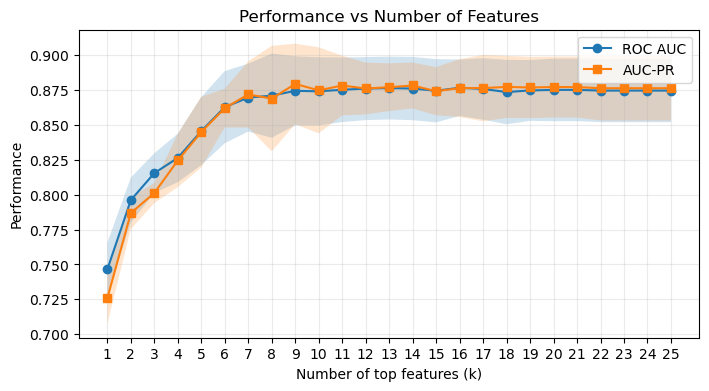

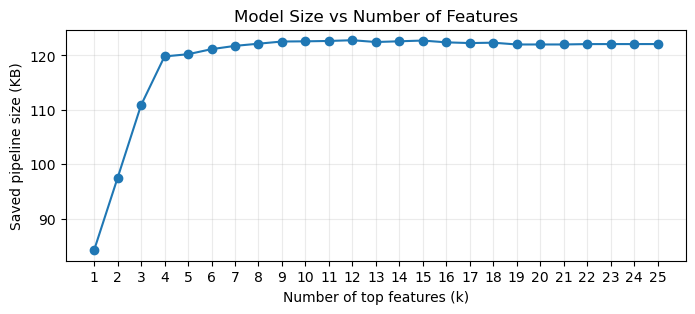

In [15]:


df_topk = pd.read_csv("../artifacts/topk_results.csv")
df_topk['model_size_kb'] = df_topk['model_size_bytes'] / 1024

# Plot AUC & AUC-PR
plt.figure(figsize=(8,4))
plt.plot(df_topk['k'], df_topk['mean_auc'], marker='o', label='ROC AUC')
plt.fill_between(df_topk['k'], df_topk['mean_auc']-df_topk['std_auc'], df_topk['mean_auc']+df_topk['std_auc'], alpha=0.2)
plt.plot(df_topk['k'], df_topk['mean_avg_precision'], marker='s', label='AUC-PR')
plt.fill_between(df_topk['k'], df_topk['mean_avg_precision']-df_topk['std_avg_precision'], df_topk['mean_avg_precision']+df_topk['std_avg_precision'], alpha=0.2)
plt.xlabel("Number of top features (k)")
plt.ylabel("Performance")
plt.title("Performance vs Number of Features")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(df_topk['k'])
plt.savefig("../figures/perf_vs_k.png", dpi=200, bbox_inches='tight')
plt.show()

# Plot model size
plt.figure(figsize=(8,3))
plt.plot(df_topk['k'], df_topk['model_size_kb'], marker='o')
plt.xlabel("Number of top features (k)")
plt.ylabel("Saved pipeline size (KB)")
plt.title("Model Size vs Number of Features")
plt.grid(alpha=0.25)
plt.xticks(df_topk['k'])
plt.savefig("../figures/size_vs_k.png", dpi=200, bbox_inches='tight')
plt.show()


In [17]:
pipe6 = joblib.load("../artifacts/topk_models/pipeline_top6.joblib")
print(pipe6)

# See model params and feature selector indices
print("Pipeline steps:", pipe6.named_steps.keys())
print("Model:", pipe6.named_steps['model'])
sel = pipe6.named_steps['selector']
print("Selector indices:", sel.indices)   # ColumnSelector stored the indices


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                               

In [18]:
# get transformed feature names (we used preprocessor_fixed earlier)
pre = pipe6.named_steps['preprocessor']
def get_feature_names(ct):
    names=[]
    for name, transformer, cols in ct.transformers_:
        if hasattr(transformer, 'named_steps'):
            last = list(transformer.named_steps.values())[-1]
            if hasattr(last, 'get_feature_names_out'):
                names.extend(last.get_feature_names_out(cols).tolist())
            else:
                names.extend(cols)
        else:
            if hasattr(transformer, 'get_feature_names_out'):
                names.extend(transformer.get_feature_names_out(cols).tolist())
            else:
                names.extend(cols)
    return names

all_names = get_feature_names(pre)
indices = pipe6.named_steps['selector'].indices
topk_names = [all_names[i] for i in indices]
print("Top-k feature names:", topk_names)

Top-k feature names: ['cp_asymptomatic', 'exang_False', 'cp_atypical angina', 'chol', 'sex_Female', 'oldpeak']
